In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import matplotlib.patheffects as PathEffects
import numpy as np
import shoji
from typing import List, Optional
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import scipy as sci
import scanpy as sc
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind

In [ ]:
#Save h5ad file from url: https://storage.googleapis.com/linnarsson-lab-glioblastoma/woundresponse/bulk_samples_GBO_treated.h5ad
#Alternatively follow the instructions at https://github.com/linnarsson-lab/shoji/blob/master/notebooks/GettingStarted_Shoji.ipynb under "Download example dataset" to create a temporary directory for the file.

In [7]:
# Load the sample data into your local Shoji database
GBO = sc.read_h5ad('/home/jesper/data/bulk_samples_GBO_treated.h5ad') #Change to the path where the h5ad file has been saved 

In [8]:
GBO.obs

,>=Q30,Condition,Mreads,Sample,Sample_Condition,Sample_Time_Condition,Time,Time_Condition,Time_Sample
CellID,,,,,,,,,
P30308_101,88.85,-P-H,21.35,SL007,SL007 _-P-H,SL007 0h,0h,0h,0h_SL007
P30308_102,89.27,-P-H,22.31,SL013,SL013 _-P-H,SL013 0h,0h,0h,0h_SL013
P30308_103,89.24,-P-H,23.64,SL014,SL014 _-P-H,SL014 0h,0h,0h,0h_SL014
P30308_104,89.15,-P-H,26.13,SL027A,SL027A_-P-H,SL027A 0h,0h,0h,0h_SL027A
P30308_106,89.11,-P+H,23.06,SL013,SL013 _-P+H,SL013 H24h,24h,H24h,24h_SL013
P30308_107,89.10,-P+H,20.10,SL014,SL014 _-P+H,SL014 H24h,24h,H24h,24h_SL014
P30308_108,89.48,-P+H,25.10,SL027A,SL027A_-P+H,SL027A H24h,24h,H24h,24h_SL027A
P30308_109,89.07,+P+H,26.24,SL007,SL007 _+P+H,SL007 HP24h,24h,HP24h,24h_SL007
P30308_110,89.21,+P+H,25.95,SL013,SL013 _+P+H,SL013 HP24h,24h,HP24h,24h_SL013


## Figure 2b

### Full list of MES1 and MES2 genes

In [25]:
MES1 = np.array(["CHI3L1","ANXA2","ANXA1","CD44","VIM","MT2A","C1S","NAMPT","EFEMP1","C1R","SOD2","IFITM3","TIMP1","SPP1","A2M","S100A11","MT1X","S100A10","FN1","LGALS1","S100A16","CLIC1","MGST1","RCAN1","TAGLN2","NPC2","SERPING1","TCIM","EMP1","APOE","CTSB","C3","LGALS3","MT1E","EMP3","SERPINA3","ACTN1","PRDX6","IGFBP7","SERPINE1","PLP2","MGP","CLIC4","GFPT2","GSN","NNMT","TUBA1C","GJA1","TNFRSF1A","WWTR1"])
MES2 = np.array(["HILPDA","ADM","DDIT3","NDRG1","HERPUD1","DNAJB9","TRIB3","ENO2","AKAP12","SQSTM1","MT1X","ATF3","NAMPT","NRN1","SLC2A1","BNIP3","LGALS3","INSIG2","IGFBP3","PPP1R15A","VIM","PLOD2","GBE1","SLC2A3","FTL","WARS1","ERO1A","XPOT","HSPA5","GDF15","ANXA2","EPAS1","LDHA","P4HA1","SERTAD1","PFKP","PGK1","EGLN3","SLC6A6","CA9","BNIP3L","RPL21","TRAM1","UFM1","ASNS","GOLT1B","ANGPTL4","SLC39A14","CDKN1A","HSPA9"])
gene_list = np.concatenate((MES1, MES2))
_, i = np.unique(gene_list, return_index=True)
gene_list = gene_list[np.sort(i)]

### Calculate fraction of total UMIs originating from the MES-genes

In [20]:
df = GBO.to_df(layer=None) #Save as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
MES_df = df[gene_list] # MES-genes dataframe
df_mes = MES_df.sum(axis=1) #total UMIs MES genes per sample
#Sort samples based on time
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
#Fraction of MES-genes UMIs of total per timepoint 
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Sample_Condition)
merged1 = merged.rename(index=rename) #rename index 
merged1 = merged1.multiply(100) #multiply by 100 (display percent)
rename = dict(GBO.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0) #condense df by merging all samples (mean) of same condition but different time points (columns)
merg = merg.multiply(100)
merg['0'] = dict(zip(merg.index,(np.repeat([merg['0'][0]], 4, axis=0))))
merg = merg.drop(['-P-H'])
merg = merg.reindex(['+P-H','-P+H','+P+H'])
merged1 = merged1.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merged1 = merged1.reindex(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H','SL007 _+P-H',
'SL013 _+P-H', 'SL014 _+P-H', 'SL027A_+P-H','SL007 _-P+H',
'SL013 _-P+H', 'SL014 _-P+H', 'SL027A_-P+H', 'SL007 _+P+H',
'SL013 _+P+H', 'SL014 _+P+H', 'SL027A_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:4]['0']], 4, axis=0)))) #Repeat values for time point zero (before treatment) for all four replicates across conditions.
merged1 = merged1.drop(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H']) #Remove time point zero 

In [21]:
merged1

,0,24,72,144
CellID,,,,
SL007 _+P-H,1.935586,2.281167,2.390662,2.198169
SL013 _+P-H,2.391747,3.238914,2.897211,3.218274
SL014 _+P-H,2.786494,3.996217,3.593984,2.876063
SL027A_+P-H,1.966679,1.883121,2.281887,2.251539
SL007 _-P+H,1.935586,NaN,3.388311,1.836658
SL013 _-P+H,2.391747,3.844799,5.261470,2.048356
SL014 _-P+H,2.786494,3.612606,4.624027,2.983608
SL027A_-P+H,1.966679,3.060026,3.638747,1.727970
SL007 _+P+H,1.935586,3.462254,3.744384,2.095644


### Abbreviations in dataframe
#### 'P' = Plasma, 'H' = Hypoxia
#### no treatment (-P-H), plasma (+P-H), hypoxia (-P+H), hypoxia+plasma (+P+H)

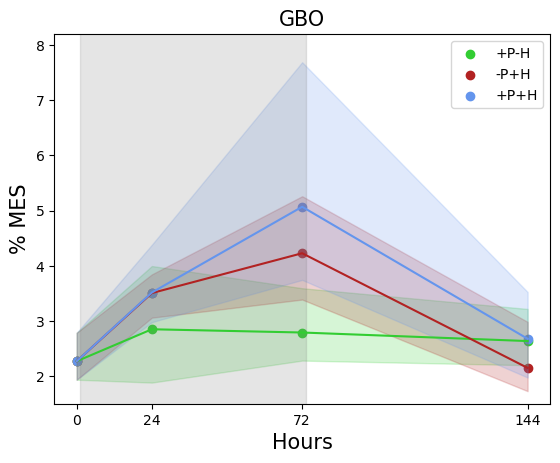

In [22]:
#Plot data (mean) excluding control-condition and create shaded areas instead of whiskers
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2) #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2)  #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2)  #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.ylim(1.5, 8.2)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
tr = numb +1.1 #shaded area, shift a bit to the right
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

In [23]:
# Control experiment was performed separately, at a later time point and therefore also analyzed in a separate notebook:
# Figure_2B_Extended_Figure_8A(GBO_control).ipynb. 

In [26]:
GBO_c = sc.read_h5ad('/home/jesper/data/bulk_samples_GBO_control_smartseq_2025.h5ad') #Change to the path where the h5ad file has been saved 

### Integration of control data GBO (separate experiment)

In [27]:
df = GBO_c.to_df(layer=None) #Save GBO controls as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
MES_df = df[gene_list] # MES-genes dataframe
df_mes = MES_df.sum(axis=1) #total UMIs MES genes per sample
#Sort samples based on time
zero = GBO_c[GBO_c.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO_c[GBO_c.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO_c[GBO_c.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO_c[GBO_c.obs["Time"] == "144h"]
#Fraction of MES-genes UMIs of total per timepoint 
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO_c.obs.Time_Sample)
merged1_c = merged.rename(index=rename) #rename index 
merged1_c = merged1_c.multiply(100) #multiply by 100 (display percent)
rename = dict(GBO_c.obs.Sample)
merg_c = merged.rename(index=rename)
merg_c = merg_c.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merg_c = merg_c.multiply(100)
merg1_c = merg_c.mean(axis=0) #condense df by merging all samples (mean) of same condition but different time points (columns) 
merg_c

,0,24,72,144
SL007,2.822486,2.513223,1.856766,2.637098
SL013,3.559915,1.966555,1.662709,1.683068
SL014,8.099460,4.573310,4.142731,3.600167
SL027A,4.266886,2.664684,3.198863,3.068915


In [30]:
merg.loc['-P-H'] = merg1_c #Add control condtion to dataframe (treatment samples)
Max = np.max(merg_c) #Calc max and min for plotting whiskers / shaded region
Min = np.min(merg_c)

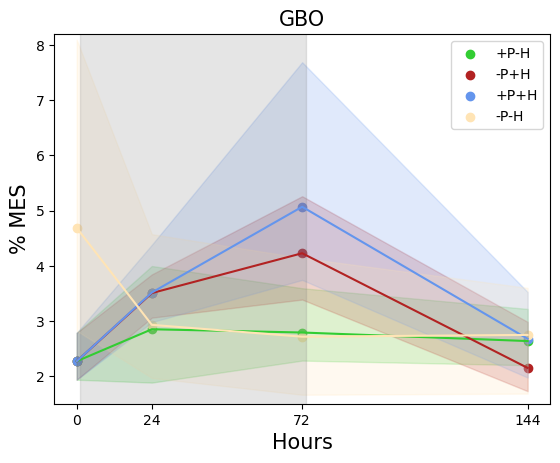

In [31]:
# Integrated with control
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='moccasin') #control
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2) #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2) #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2) #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.plot(numb, merg.iloc[3], color='moccasin') #control
plt.fill_between(numb,Min,Max, color='moccasin', alpha=0.2) #fill/shaded region instead of whiskers
plt.ylim(1.5, 8.2)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
tr = numb +1.1 #shaded area, shift a bit to the right
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

### Statistics

In [32]:
#One-sided test
#+p-h all timepoints vs start
x, p1 = mannwhitneyu(merged1[0:4]['0'], merged1[0:4]['24'], alternative='less')
x, p2 = mannwhitneyu(merged1[0:4]['0'], merged1[0:4]['72'], alternative='less')
x, p3 = mannwhitneyu(merged1[0:4]['0'], merged1[0:4]['144'], alternative='less') 
#-p+h all timepoints vs start
x, p4 = mannwhitneyu(merged1[4:8]['0'], merged1[5:8]['24'], alternative='less')
x, p5 = mannwhitneyu(merged1[4:8]['0'], merged1[4:8]['72'], alternative='less')
x, p6 = mannwhitneyu(merged1[4:8]['0'], merged1[4:8]['144'], alternative='less') 
#+p+h all timepoints vs start
x, p7 = mannwhitneyu(merged1[8:12]['0'], merged1[8:12]['24'], alternative='less')
x, p8 = mannwhitneyu(merged1[8:12]['0'], merged1[8:12]['72'], alternative='less')
x, p9 = mannwhitneyu(merged1[8:12]['0'], merged1[8:12]['144'], alternative='less') 

In [33]:
comp = ['+p-H_24vs0h','+p-H_72vs0h','+p-H_144vs0h','-p+H_24vs0h','-p+H_72vs0h','-p+H_144vs0h','+p+H_24vs0h','+p+H_72vs0h','+p+H_144vs0h']

In [34]:
x = pd.Series([p1,p2,p3,p4,p5,p6,p7,p8,p9], index =comp)
x

+p-H_24vs0h     0.342857
+p-H_72vs0h     0.171429
+p-H_144vs0h    0.171429
-p+H_24vs0h     0.028571
-p+H_72vs0h     0.014286
-p+H_144vs0h    0.757143
+p+H_24vs0h     0.014286
+p+H_72vs0h     0.014286
+p+H_144vs0h    0.171429
dtype: float64

In [35]:
#One-sided test
x, p1 =  mannwhitneyu(merged1[0:4]['72'], merged1[0:4]['144'], alternative='greater')
x, p2 =  mannwhitneyu(merged1[4:8]['72'], merged1[4:8]['144'], alternative='greater')
x, p3 = mannwhitneyu(merged1[8:12]['72'], merged1[8:12]['144'], alternative='greater')

In [36]:
p1, p2, p3

(0.24285714285714285, 0.014285714285714285, 0.014285714285714285)

In [37]:
comp = ['+p-H_72vs144h','-p+H_72vs144h','+p+H_72vs144h']
x = pd.Series([p1,p2,p3], index =comp)
x

+p-H_72vs144h    0.242857
-p+H_72vs144h    0.014286
+p+H_72vs144h    0.014286
dtype: float64

## Extended Fig 8a

In [39]:
#Add individual sample control conditions to treatment dataframe
merged1.loc['SL007_-P-H'] = merg_c.loc['SL007']
merged1.loc['SL013_-P-H'] = merg_c.loc['SL013']
merged1.loc['SL014_-P-H'] = merg_c.loc['SL014']
merged1.loc['SL027A_-P-H'] = merg_c.loc['SL027A']


### Full list other neftel-states

In [40]:
AC = np.array(["CST3","S100B","SLC1A3","HEPN1","HOPX","MT3","SPARCL1","MLC1","GFAP","FABP7","BCAN","PON2","METTL7B","SPARC","GATM","RAMP1","PMP2","AQP4","DBI","EDNRB","PTPRZ1","CLU","PMP22","ATP1A2","S100A16","HEY1","PCDHGC3","TTYH1","NDRG2","PRCP","ATP1B2","AGT","PLTP","GPM6B","F3","RAB31","PLPP3","ANXA5","TSPAN7"])
OPC = np.array(["BCAN","PLP1","GPR17","FIBIN","LHFPL3","OLIG1","PSAT1","SCRG1","OMG","APOD","SIRT2","TNR","THY1","PHYHIPL","SOX2-OT","NKAIN4","PLPPR1","PTPRZ1","VCAN","DBI","PMP2","CNP","TNS3","LIMA1","CA10","PCDHGC3","CNTN1","SCD5","P2RX7","CADM2","TTYH1","FGF12","PACC1","NEU4","FXYD6","RNF13","RTKN","GPM6B","LMF1","ALCAM","PGRMC1","PLAAT1","BCAS1","RAB31","PLLP","FABP5","NLGN3","SERINC5","EPB41L2","GPR37L1"])
NPC1 = np.array(["DLL3","DLL1","SOX4","TUBB3","HES6","TAGLN3","NEU4","MARCKSL1","CD24","STMN1","TCF12","BEX1","OLIG1","MAP2","FXYD6","PTPRS","MLLT11","NPPA","BCAN","MEST","ASCL1","BTG2","DCX","NXPH1","JPT1","PFN2","SCG3","MYT1","CHD7","ADGRG1","TUBA1A","PCBP4","ETV1","SHD","TNR","AMOTL2","DBN1","HIP1","ABAT","ELAVL4","LMF1","GRIK2","SERINC5","TSPAN13","ELMO1","GLCCI1","SEZ6L","LRRN1","SEZ6","SOX11"])
NPC2 = np.array(["STMN2","CD24","RND3","NSG2","TUBB3","MIAT","DCX","NSG1","ELAVL4","MLLT11","DLX6-AS1","SOX11","NREP","FNBP1L","TAGLN3","STMN4","DLX5","SOX4","MAP1B","RBFOX2","IGFBPL1","STMN1","JPT1","DPYSL3","SEPTIN3","PKIA","ATP1B1","DYNC1I1","CD200","SNAP25","PAK3","NDRG4","KIF5A","UCHL1","ENO2","KIF5C","DDAH2","TUBB2A","LBH","LINC01102","TCF4","GNG3","NFIB","DPYSL5","CRABP1","DBN1","NFIX","CEP170","BLCAP"])
NPC = np.concatenate((NPC1, NPC2))

In [45]:
df = GBO.to_df(layer=None) #Save as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
OPC_df = df[OPC] # OPC-genes dataframe
df_OPC = OPC_df.sum(axis=1) #total UMIs OPC genes per sample
#Sort samples based on time
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_OPC = df_OPC[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_OPC = df_OPC[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_OPC = df_OPC[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_OPC = df_OPC[six.obs.index]
#Fraction of OPC-genes UMIs of total per timepoint 
OPC_zero = zero_OPC/zero_all
OPC_one = one_OPC/one_all
OPC_three = three_OPC/three_all
OPC_six = six_OPC/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([OPC_zero, OPC_one, OPC_three, OPC_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Sample_Condition)
merged1 = merged.rename(index=rename) #rename index 
merged1 = merged1.multiply(100) #multiply by 100 (display percent)
rename = dict(GBO.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0) #condense df by merging all samples (mean) of same condition but different time points (columns)
merg = merg.multiply(100)
merg['0'] = dict(zip(merg.index,(np.repeat([merg['0'][0]], 4, axis=0))))
merg = merg.drop(['-P-H'])
merg = merg.reindex(['+P-H','-P+H','+P+H'])
merged1 = merged1.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merged1 = merged1.reindex(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H','SL007 _+P-H',
'SL013 _+P-H', 'SL014 _+P-H', 'SL027A_+P-H','SL007 _-P+H',
'SL013 _-P+H', 'SL014 _-P+H', 'SL027A_-P+H', 'SL007 _+P+H',
'SL013 _+P+H', 'SL014 _+P+H', 'SL027A_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:4]['0']], 4, axis=0)))) #Repeat values for time point zero (before treatment) for all four replicates across conditions.
merged1 = merged1.drop(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H']) #Remove time point zero 

In [46]:
df = GBO_c.to_df(layer=None) #Save GBO controls as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
OPC_df = df[OPC] # OPC-genes dataframe
df_OPC = OPC_df.sum(axis=1) #total UMIs OPC genes per sample
#Sort samples based on time
zero = GBO_c[GBO_c.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_OPC = df_OPC[zero.obs.index]
one = GBO_c[GBO_c.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_OPC = df_OPC[one.obs.index]
three = GBO_c[GBO_c.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_OPC = df_OPC[three.obs.index]
six = GBO_c[GBO_c.obs["Time"] == "144h"]
#Fraction of OPC-genes UMIs of total per timepoint 
six_all = df_all[six.obs.index]
six_OPC = df_OPC[six.obs.index]
OPC_zero = zero_OPC/zero_all
OPC_one = one_OPC/one_all
OPC_three = three_OPC/three_all
OPC_six = six_OPC/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([OPC_zero, OPC_one, OPC_three, OPC_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO_c.obs.Time_Sample)
merged1_c = merged.rename(index=rename) #rename index 
merged1_c = merged1_c.multiply(100) #multiply by 100 (display percent)
rename = dict(GBO_c.obs.Sample)
merg_c = merged.rename(index=rename)
merg_c = merg_c.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merg_c = merg_c.multiply(100)
merg1_c = merg_c.mean(axis=0) #condense df by merging all samples (mean) of same condition but different time points (columns) 
merg.loc['-P-H'] = merg1_c #Add control condtion to dataframe (treatment samples)
Max = np.max(merg_c) #Calc max and min for plotting whiskers / shaded region
Min = np.min(merg_c)

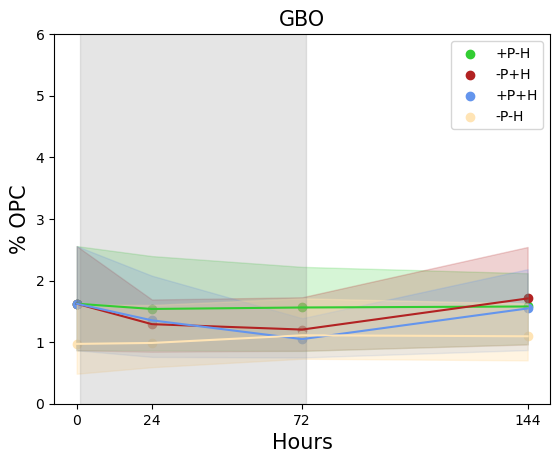

In [47]:
# Integrated with control
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2) #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2) #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2) #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.plot(numb, merg.iloc[3], color='moccasin')
plt.fill_between(numb,Min,Max, color='moccasin', alpha=0.4)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% OPC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
tr = numb +1.1 #shaded area, shift a bit to the right
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

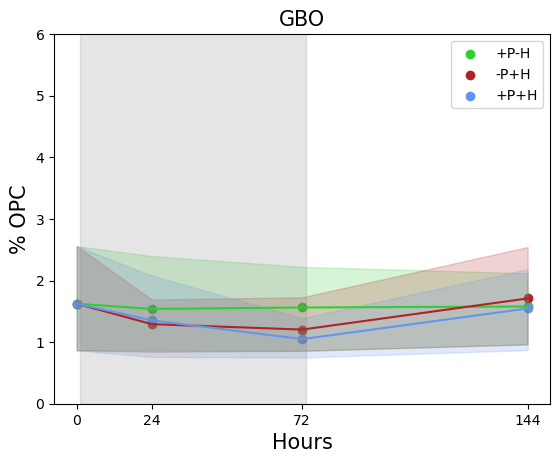

In [48]:
#Plot data (mean) excluding control-condition 
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2)
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2)
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2)
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% OPC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
tr = numb +1.1
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

In [57]:
df = GBO.to_df(layer=None) #Save as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
AC_df = df[AC] # AC-genes dataframe
df_AC = AC_df.sum(axis=1) #total UMIs AC genes per sample
#Sort samples based on time
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_AC = df_AC[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_AC = df_AC[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_AC = df_AC[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_AC = df_AC[six.obs.index]
#Fraction of AC-genes UMIs of total per timepoint 
AC_zero = zero_AC/zero_all
AC_one = one_AC/one_all
AC_three = three_AC/three_all
AC_six = six_AC/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([AC_zero, AC_one, AC_three, AC_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Sample_Condition)
merged1 = merged.rename(index=rename) #rename index 
merged1 = merged1.multiply(100) #multiply by 100 (display percent)
rename = dict(GBO.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0) #condense df by merging all samples (mean) of same condition but different time points (columns)
merg = merg.multiply(100)
merg['0'] = dict(zip(merg.index,(np.repeat([merg['0'][0]], 4, axis=0))))
merg = merg.drop(['-P-H'])
merg = merg.reindex(['+P-H','-P+H','+P+H'])
merged1 = merged1.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merged1 = merged1.reindex(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H','SL007 _+P-H',
'SL013 _+P-H', 'SL014 _+P-H', 'SL027A_+P-H','SL007 _-P+H',
'SL013 _-P+H', 'SL014 _-P+H', 'SL027A_-P+H', 'SL007 _+P+H',
'SL013 _+P+H', 'SL014 _+P+H', 'SL027A_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:4]['0']], 4, axis=0)))) #Repeat values for time point zero (before treatment) for all four replicates across conditions.
merged1 = merged1.drop(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H']) #Remove time point zero 

In [58]:
df = GBO_c.to_df(layer=None) #Save GBO controls as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
AC_df = df[AC] # AC-genes dataframe
df_AC = AC_df.sum(axis=1) #total UMIs AC genes per sample
#Sort samples based on time
zero = GBO_c[GBO_c.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_AC = df_AC[zero.obs.index]
one = GBO_c[GBO_c.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_AC = df_AC[one.obs.index]
three = GBO_c[GBO_c.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_AC = df_AC[three.obs.index]
six = GBO_c[GBO_c.obs["Time"] == "144h"]
#Fraction of AC-genes UMIs of total per timepoint 
six_all = df_all[six.obs.index]
six_AC = df_AC[six.obs.index]
AC_zero = zero_AC/zero_all
AC_one = one_AC/one_all
AC_three = three_AC/three_all
AC_six = six_AC/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([AC_zero, AC_one, AC_three, AC_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO_c.obs.Time_Sample)
merged1_c = merged.rename(index=rename) #rename index 
merged1_c = merged1_c.multiply(100) #multiply by 100 (display percent)
rename = dict(GBO_c.obs.Sample)
merg_c = merged.rename(index=rename)
merg_c = merg_c.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merg_c = merg_c.multiply(100)
merg1_c = merg_c.mean(axis=0) #condense df by merging all samples (mean) of same condition but different time points (columns) 
merg.loc['-P-H'] = merg1_c #Add control condtion to dataframe (treatment samples)
Max = np.max(merg_c) #Calc max and min for plotting whiskers / shaded region
Min = np.min(merg_c)

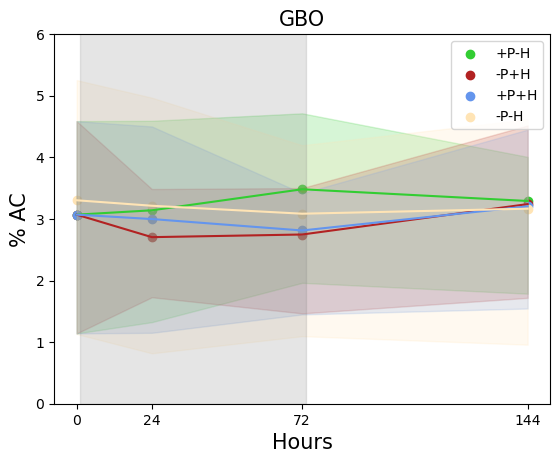

In [59]:
# Integrated with control
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2) #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2) #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2) #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.plot(numb, merg.iloc[3], color='moccasin')
plt.fill_between(numb,Min,Max, color='moccasin', alpha=0.2)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% AC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
tr = numb +1.1 #shaded area, shift a bit to the right
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

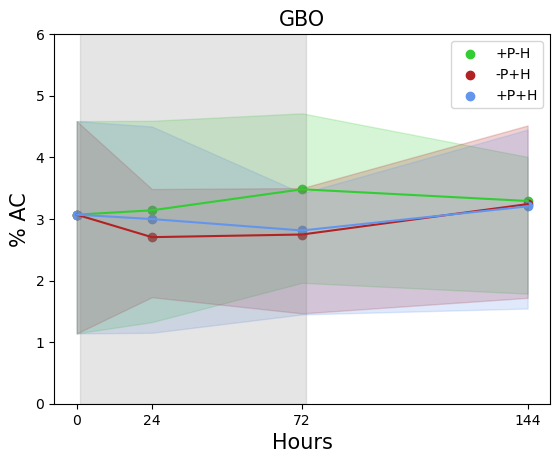

In [60]:
#Plot data (mean) excluding control-condition 
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2)
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2)
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2)
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% AC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
tr = numb +1.1
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

In [61]:
df = GBO.to_df(layer=None) #Save as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
NPC_df = df[NPC] # NPC-genes dataframe
df_NPC = NPC_df.sum(axis=1) #total UMIs NPC genes per sample
#Sort samples based on time
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_NPC = df_NPC[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_NPC = df_NPC[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_NPC = df_NPC[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_NPC = df_NPC[six.obs.index]
#FrNPCtion of NPC-genes UMIs of total per timepoint 
NPC_zero = zero_NPC/zero_all
NPC_one = one_NPC/one_all
NPC_three = three_NPC/three_all
NPC_six = six_NPC/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([NPC_zero, NPC_one, NPC_three, NPC_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Sample_Condition)
merged1 = merged.rename(index=rename) #rename index 
merged1 = merged1.multiply(100) #multiply by 100 (display percent)
rename = dict(GBO.obs.Condition)
merg = merged.rename(index=rename)
merg = merg.mean(level=0) #condense df by merging all samples (mean) of same condition but different time points (columns)
merg = merg.multiply(100)
merg['0'] = dict(zip(merg.index,(np.repeat([merg['0'][0]], 4, axis=0))))
merg = merg.drop(['-P-H'])
merg = merg.reindex(['+P-H','-P+H','+P+H'])
merged1 = merged1.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merged1 = merged1.reindex(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H','SL007 _+P-H',
'SL013 _+P-H', 'SL014 _+P-H', 'SL027A_+P-H','SL007 _-P+H',
'SL013 _-P+H', 'SL014 _-P+H', 'SL027A_-P+H', 'SL007 _+P+H',
'SL013 _+P+H', 'SL014 _+P+H', 'SL027A_+P+H'])
merged1['0'] = dict(zip(merged1.index,np.concatenate(np.repeat([merged1[0:4]['0']], 4, axis=0)))) #Repeat values for time point zero (before treatment) for all four replicates NPCross conditions.
merged1 = merged1.drop(['SL007 _-P-H', 'SL013 _-P-H', 'SL014 _-P-H', 'SL027A_-P-H']) #Remove time point zero 

In [62]:
df = GBO_c.to_df(layer=None) #Save GBO controls as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
NPC_df = df[NPC] # NPC-genes dataframe
df_NPC = NPC_df.sum(axis=1) #total UMIs NPC genes per sample
#Sort samples based on time
zero = GBO_c[GBO_c.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_NPC = df_NPC[zero.obs.index]
one = GBO_c[GBO_c.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_NPC = df_NPC[one.obs.index]
three = GBO_c[GBO_c.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_NPC = df_NPC[three.obs.index]
six = GBO_c[GBO_c.obs["Time"] == "144h"]
#FrNPCtion of NPC-genes UMIs of total per timepoint 
six_all = df_all[six.obs.index]
six_NPC = df_NPC[six.obs.index]
NPC_zero = zero_NPC/zero_all
NPC_one = one_NPC/one_all
NPC_three = three_NPC/three_all
NPC_six = six_NPC/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([NPC_zero, NPC_one, NPC_three, NPC_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO_c.obs.Time_Sample)
merged1_c = merged.rename(index=rename) #rename index 
merged1_c = merged1_c.multiply(100) #multiply by 100 (display percent)
rename = dict(GBO_c.obs.Sample)
merg_c = merged.rename(index=rename)
merg_c = merg_c.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merg_c = merg_c.multiply(100)
merg1_c = merg_c.mean(axis=0) #condense df by merging all samples (mean) of same condition but different time points (columns) 
merg.loc['-P-H'] = merg1_c #Add control condtion to dataframe (treatment samples)
Max = np.max(merg_c) #Calc max and min for plotting whiskers / shaded region
Min = np.min(merg_c)

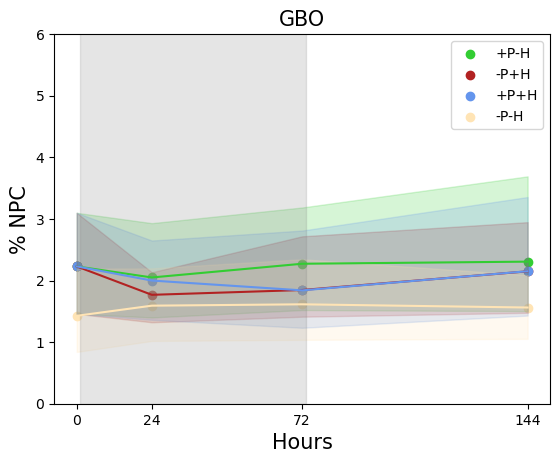

In [63]:
# Integrated with control
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='moccasin')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2) #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2) #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2) #fill/shaded region instead of whiskers
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.plot(numb, merg.iloc[3], color='moccasin')
plt.fill_between(numb,Min,Max, color='moccasin', alpha=0.2)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% NPC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
tr = numb +1.1 #shaded area, shift a bit to the right
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)

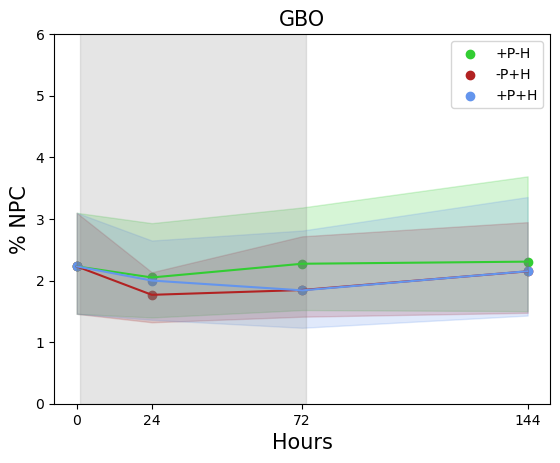

In [64]:
#Plot data (mean) excluding control-condition 
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='limegreen')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='firebrick')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='limegreen')
plt.fill_between(numb, np.min(merged1[0:4]),np.max(merged1[0:4]), color='limegreen', alpha=0.2)
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged1[0:4])).iloc[0], np.max(merged1[0:4])-merg[0:1].iloc[0]), color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[1], color='firebrick')
plt.fill_between(numb,np.min(merged1[4:8]),np.max(merged1[4:8]), color='firebrick', alpha=0.2)
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged1[4:8])).iloc[0], np.max(merged1[4:8])-merg[1:2].iloc[0]),color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[2], color='cornflowerblue')
plt.fill_between(numb,np.min(merged1[8:12]),np.max(merged1[8:12]), color='cornflowerblue', alpha=0.2)
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged1[8:12])).iloc[0], np.max(merged1[8:12])-merg[2:3].iloc[0]), color='cornflowerblue',capsize=8)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% NPC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
tr = numb +1.1
plt.fill_between(tr, 20, where= (tr < 140) & (tr > 0), color='grey', alpha=0.2)